Средняя пенсия в Забайкальском крае за 2018 год: 13197.91


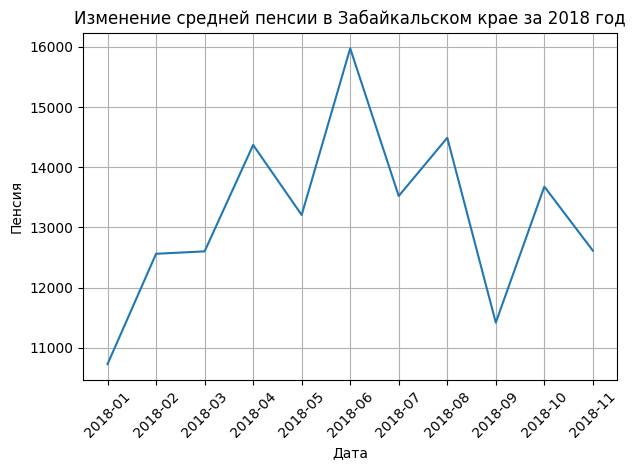

In [105]:
import requests
import matplotlib.pyplot as plt
import sys
from http import HTTPStatus

try:
    url = requests.get("https://raw.githubusercontent.com/dm-fedorov/python_basic/master/data/opendata.stat")
    if url.raise_for_status() == 404:
        print(f"Ошибка при загрузке данных: {r.raise_for_status()}")
        sys.exit(1)
    data = url.text
except requests.exceptions.RequestException as e:
    print(f"Ошибка при загрузке данных: {e}")
    sys.exit(1)

lines = data.strip().split("\n")
lines = lines[1::]
pensions_2018 = []

dates = []
values = []

for line in lines:
    parts = line.split(",")
    
    name = parts[0]
    region = parts[1]
    date = parts[2][:-3:]
    value = int(parts[3])
    if len(parts) < 4: # строка может содержать недостаточно данных
        continue 
    
    if name == "Средняя пенсия" and region == "Забайкальский край" and date[:4:] == "2018":
        pensions_2018.append(value)
        dates.append(date)
        values.append(value)

average_pension = sum(pensions_2018) / len(pensions_2018)
print("Средняя пенсия в Забайкальском крае за 2018 год:", round(average_pension, 2))

plt.plot(dates, values)
plt.title("Изменение средней пенсии в Забайкальском крае за 2018 год")
plt.xlabel("Дата")
plt.ylabel("Пенсия")
plt.xticks(rotation=45) # чтоб по оси абсцисс не было текста друг на друге
plt.grid(True)
plt.tight_layout() # чтоб не было обрезанного окна (добавил из-за xticks)
plt.show()

In [110]:
class MyFile:
    def __init__(self, source, mode):
        
        if not source or (type(source) != str):
            raise ValueError("Источник должен быть непустой строкой")
        
        valid_modes = ["read", "write", "append", "url"]
        
        if mode not in valid_modes:
            raise ValueError(f"Доступные режимы: {', '.join(valid_modes)}")
        
        self.source = source
        self.mode = mode

    def read(self):
        try:
            with open(self.source, "r", encoding="utf-8") as f:
                return f.read()
        except FileNotFoundError:
            return "Ошибка: файл не найден"
        except PermissionError:
            return "Ошибка: нет прав доступа к файлу"

    def write(self, text):
        if self.mode == "write":
            mode = "w"
        elif self.mode == "append":
            mode = "a"
        try:
            with open(self.source, mode, encoding="utf-8") as f:
                f.write(text)
        except FileNotFoundError:
            return "Ошибка: файл не найден"
        except PermissionError:
            return "Ошибка: нет прав доступа к файлу"

    def read_url(self):
        try:
            url = requests.get(self.source)
            return url.text
        except requests.exceptions.ConnectionError:
            return "Ошибка: не удалось подключиться к сайту"
        except requests.exceptions.Timeout:
            return "Ошибка: время ожидания истекло"
            
    def write_url(self, filename):
        try:
            url = requests.get(self.source)
        except requests.exceptions.ConnectionError:
            return "Ошибка: не удалось подключиться к сайту"
        except requests.exceptions.Timeout:
            return "Ошибка: время ожидания истекло"
        with open(filename, "w", encoding="utf-8") as f:
            f.write(url.text)

In [111]:
file = MyFile("text.txt", "write")
text = file.write("привет-") # происходит запись строки в файл

In [112]:
file = MyFile("text.txt", "read")
text = file.read() # происходит чтение в виде str
print(text)

привет-


In [113]:
file = MyFile("text.txt", "append")
text = file.write("привет!") # происходит добавление строки в конец файла

In [114]:
file = MyFile("text.txt", "read")
text = file.read() # происходит чтение в виде str
print(text)

привет-привет!


In [115]:
file = MyFile("https://blog.dfedorov.spb.ru", "url")
text = file.read_url()
print(text)

Ошибка: не удалось подключиться к сайту


In [116]:
file = MyFile("https://dfedorov.spb.ru", "url")
text = file.read_url()
print(text)
# происходит запись содержимого страницы по URL в указанный файл
result = file.write_url("text.txt")
print(result)

<html>
  <head>
  <title>Дмитрий Федоров про образование в области кибербезопасности: как сократить разрыв между выпускниками и рынком труда</title>
    
<meta name="description" content="Дмитрий Федоров про образование в области кибербезопасности: как сократить разрыв между выпускниками и рынком труда" />
<link href="styles.css" rel="stylesheet">  
<link rel="icon" type="image/png" href="logo_df.png" />
   
<!-- Yandex.Metrika counter -->
<script type="text/javascript" >
   (function(m,e,t,r,i,k,a){m[i]=m[i]||function(){(m[i].a=m[i].a||[]).push(arguments)};
   m[i].l=1*new Date();k=e.createElement(t),a=e.getElementsByTagName(t)[0],k.async=1,k.src=r,a.parentNode.insertBefore(k,a)})
   (window, document, "script", "https://mc.yandex.ru/metrika/tag.js", "ym");

   ym(25964164, "init", {
        clickmap:true,
        trackLinks:true,
        accurateTrackBounce:true
   });
</script>
<noscript><div><img src="https://mc.yandex.ru/watch/25964164" style="position:absolute; left:-9999px;" alt

In [117]:
file = MyFile("text1.txt", "read")
text = file.read()
print(text)

Ошибка: файл не найден


In [118]:
file = MyFile("C:\\Program Files (x86)\\MyTestX\\language.txt", "write")
result = file.write("text.txt")
print(result)

Ошибка: нет прав доступа к файлу


In [119]:
file = MyFile(12, "read")
text = file.read()
print(text)

ValueError: Источник должен быть непустой строкой

In [120]:
file = MyFile("text.txt", "take")
text = file.read()
print(text)

ValueError: Доступные режимы: read, write, append, url

In [122]:
file = MyFile("https://raw.githubusercontent.com/dm-fedorov/python_basic/master/data/opendaa.stat", "url")
text = file.read_url()
print(text)
# происходит запись содержимого страницы по URL в указанный файл
result = file.write_url("text.txt")  # None - файл text.txt успешно перезапишется
print(result)

404: Not Found
None
